# TELEPATI 8.0 — AgriData Intelligence Race
## Rice Disease Object Detection — End-to-End Reproducible Pipeline

**Compliance statement**: No external pretrained weights (model built from an
architecture-only `.yaml` definition, `pretrained=False`, verified in Block 6
via source inspection and empty-checkpoint-cache checks). No external
dataset. No LLM/API dataset processing. Official dataset only. Canonical
11-class mapping (verified against the actual dataset with zero unmapped
categories). Deterministic seeding. `YOLO_OFFLINE=1` enforced throughout.

This notebook demonstrates the complete pipeline from raw dataset to final
trained model, reusing the same tested code (`src/agridata/`, `scripts/`)
used and verified throughout development. Full audit trail for every step
below is under `artifacts/` and `artifacts/audit/`.

By default (`SKIP_TRAINING = True`, see Section 12), this notebook loads the
already-trained final model rather than retraining from scratch, so
"Restart & Run All" completes in a few minutes. The exact training code and
frozen configuration used to produce that model are fully shown and
functional — set `SKIP_TRAINING = False` to reproduce the full ~3.3-hour
training run.

## 1. Project & Environment Information

In [1]:
import sys
from pathlib import Path

# No personal absolute path is hardcoded: resolve the project root relative
# to this notebook's own location, so it works regardless of where the
# repository is cloned.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src" / "agridata").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent  # allow running from notebooks/ or the project root
assert (PROJECT_ROOT / "src" / "agridata").exists(), "Could not locate the agridata package — run this notebook from the project root or notebooks/."

sys.path.insert(0, str(PROJECT_ROOT / "src"))
print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/macbookpro/Projects/agridata


In [2]:
from agridata.reproducibility.environment import capture_environment_snapshot

env = capture_environment_snapshot()
print(f"Python version: {env['python_version']}")
print(f"Platform: {env['platform']['platform_string']}")
print(f"Resolved device: {env['device']['resolved_device']} (Apple Silicon: {env['device']['is_apple_silicon']})")
print(f"torch: {env['device']['torch_version']}  |  CUDA available: {env['device']['cuda_available']}  |  MPS available: {env['device']['mps_available']}")
print(f"Git commit (at notebook execution time): {env['git_commit']}")
print(f"Git working tree clean: {env['git_status']['clean']}")

Python version: 3.11.16
Platform: macOS-26.2-arm64-arm-64bit
Resolved device: mps (Apple Silicon: True)
torch: 2.14.0  |  CUDA available: False  |  MPS available: True
Git commit (at notebook execution time): 05725f1729bf6386c5cce84e508eec8f9b799ce8
Git working tree clean: True


## 2. Imports

In [3]:
import json
import subprocess
import hashlib
import random

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import yaml

from agridata.seed import set_global_seed
from agridata.device import detect_device
from agridata.dataset.mapping import CANONICAL_CLASSES, build_mapping_report
from agridata.dataset.stats import load_canonical_split
from agridata.visualization.images import draw_annotated_image
from agridata.training.train import build_compliant_model, run_training

## 3. Global Configuration & Dataset Path

The official dataset path is configurable and resolved relative to the
project root (never a personal absolute path). If your dataset lives
elsewhere, change `DATASET_ROOT` below.

In [4]:
with open(PROJECT_ROOT / "configs" / "final_model_config.yaml") as f:
    FINAL_CONFIG = yaml.safe_load(f)

DATASET_ROOT = PROJECT_ROOT / "Telepati 8.0 Datasets"
assert DATASET_ROOT.exists(), (
    f"Official dataset not found at {DATASET_ROOT}. "
    "Set DATASET_ROOT to wherever you placed the official TELEPATI 8.0 dataset."
)

print(f"Dataset root: {DATASET_ROOT}")
print(f"Final model config ({PROJECT_ROOT / 'configs' / 'final_model_config.yaml'}):")
for k, v in FINAL_CONFIG.items():
    print(f"  {k}: {v}")

Dataset root: /Users/macbookpro/Projects/agridata/Telepati 8.0 Datasets
Final model config (/Users/macbookpro/Projects/agridata/configs/final_model_config.yaml):
  seed: 42
  model_arch: yolov8n.yaml
  pretrained: False
  data_yaml: data/prepared/data.yaml
  image_size: 640
  batch_size: 16
  optimizer: AdamW
  learning_rate: 0.001
  momentum: 0.9
  weight_decay: 0.0005
  scheduler: linear
  flipud: 0.0
  fraction: 1.0
  epochs: 20
  patience: 8
  workers: 2
  device: auto


## 4. Random Seed

In [5]:
SEED = FINAL_CONFIG["seed"]
set_global_seed(SEED)
print(f"Global seed set to {SEED} (python random, numpy, torch — see src/agridata/seed.py)")

Global seed set to 42 (python random, numpy, torch — see src/agridata/seed.py)


## 5. Dataset Inspection

Quick summary counts here (fast). The full forensic audit — duplicate
detection, bounding-box validation, cross-split leakage check, image
corruption checks — is a separate, more expensive script:
`scripts/audit_dataset.py` → `artifacts/audit/dataset_audit_report.md`.

In [6]:
for split in ["train", "valid", "test"]:
    with open(DATASET_ROOT / split / "_annotations.coco.json") as f:
        data = json.load(f)
    print(f"{split:6s}: {len(data['images']):5d} images | {len(data['annotations']):6d} annotations | {len(data['categories'])} raw categories")

train : 10133 images |  20163 annotations | 21 raw categories
valid :  2106 images |   4888 annotations | 21 raw categories
test  :  1059 images |   2670 annotations | 21 raw categories


## 6. Annotation Inspection & Canonical Class Mapping (11 classes)

In [7]:
print(f"{len(CANONICAL_CLASSES)} canonical classes:")
for i, c in enumerate(CANONICAL_CLASSES):
    print(f"  model_class_id={i}: {c}")

with open(DATASET_ROOT / "train" / "_annotations.coco.json") as f:
    train_raw = json.load(f)
mapping_report = build_mapping_report(train_raw["categories"])
print(f"\nRaw categories in train split: {mapping_report['total_raw_categories']}")
print(f"Mapped to canonical classes: {len(mapping_report['mapped'])}")
print(f"Supercategory placeholders (excluded, not detection targets): {[p['raw_name'] for p in mapping_report['supercategory_placeholders']]}")
print(f"Unmapped/unknown raw categories: {mapping_report['unmapped_raw_categories']} (must be empty)")
assert not mapping_report["unmapped_raw_categories"], "Unmapped raw category found — see src/agridata/dataset/mapping.py"

11 canonical classes:
  model_class_id=0: Bacterial leaf blight
  model_class_id=1: Bacterial panicle blight
  model_class_id=2: Blast
  model_class_id=3: Brown spot
  model_class_id=4: False smut
  model_class_id=5: Healthy
  model_class_id=6: Leaf roller
  model_class_id=7: Leaf scald
  model_class_id=8: Narrow brown
  model_class_id=9: Sheath blight
  model_class_id=10: Tungro



Raw categories in train split: 21
Mapped to canonical classes: 18
Supercategory placeholders (excluded, not detection targets): ['Leaf-blight', 'Rice-Leaf-Diseasee', 'paddy']
Unmapped/unknown raw categories: [] (must be empty)


## 7. Data Cleaning / Validation — Cross-Split Leakage Check

Loads the existing forensic audit report (see Section 5's note) rather than
re-hashing all ~13,300 images inline, which would make this notebook slow to
run. Regenerate that report with `scripts/audit_dataset.py` if it does not
exist yet.

In [8]:
audit_report_path = PROJECT_ROOT / "artifacts" / "audit" / "dataset_audit_report.json"
if audit_report_path.exists():
    with open(audit_report_path) as f:
        audit = json.load(f)
    overlap = audit["cross_split_overlap"]["content_hash_overlap"]
    for pair, matches in overlap.items():
        print(f"{pair}: {len(matches)} exact byte-duplicate image(s) found")
        for m in matches:
            print(f"    {m}")
    print("\nConfirmed exact duplicates are excluded from the prepared TRAIN manifest — see Section 8.")
else:
    print(f"No existing audit report at {audit_report_path}. Run: python scripts/audit_dataset.py --dataset-root \"{DATASET_ROOT}\"")

train_vs_valid: 0 exact byte-duplicate image(s) found


train_vs_test: 1 exact byte-duplicate image(s) found
    {'hash': '04871474346779054b65889680248dd2', 'train': 'leaf_scald-230-_jpg.rf.b33be69848eb828d425b5c8e603c01c2.jpg', 'test': 'leaf_scald-230-_jpg.rf.d871f088c1010827d3b13501d870db02.jpg'}
valid_vs_test: 0 exact byte-duplicate image(s) found

Confirmed exact duplicates are excluded from the prepared TRAIN manifest — see Section 8.


## 8. Dataset Preparation (canonical mapping applied, leakage-excluded, YOLO format)

Builds a training-ready view via symlinks into the raw dataset (no image
bytes are copied). Confirmed exact-duplicate images are excluded from the
TRAIN split only; validation/test point at the original, unmodified
directories.

In [9]:
PREPARED_DIR = PROJECT_ROOT / "data" / "prepared"

if not (PREPARED_DIR / "data.yaml").exists():
    print("Preparing dataset (regenerating the training-ready view)...")
    subprocess.run(
        [sys.executable, str(PROJECT_ROOT / "scripts" / "prepare_dataset.py"),
         "--dataset-root", str(DATASET_ROOT), "--output-dir", str(PREPARED_DIR), "--seed", str(SEED)],
        check=True, cwd=PROJECT_ROOT,
    )
else:
    print(f"Prepared dataset already exists at {PREPARED_DIR}")

with open(PREPARED_DIR / "data.yaml") as f:
    print("\n" + f.read())

Prepared dataset already exists at /Users/macbookpro/Projects/agridata/data/prepared

# Auto-generated by scripts/prepare_dataset.py — do not hand-edit.
# Regenerate by rerunning the script; this file is not committed to git.
path: /Users/macbookpro/Projects/agridata/data/prepared
train: train/images
val: valid/images
test: test/images

names:
  0: Bacterial leaf blight
  1: Bacterial panicle blight
  2: Blast
  3: Brown spot
  4: False smut
  5: Healthy
  6: Leaf roller
  7: Leaf scald
  8: Narrow brown
  9: Sheath blight
  10: Tungro



## 9. Visualization — Sample Training Images with Ground-Truth Boxes

A small, fixed number of samples (not thousands of embedded images), chosen
deterministically from the global seed.

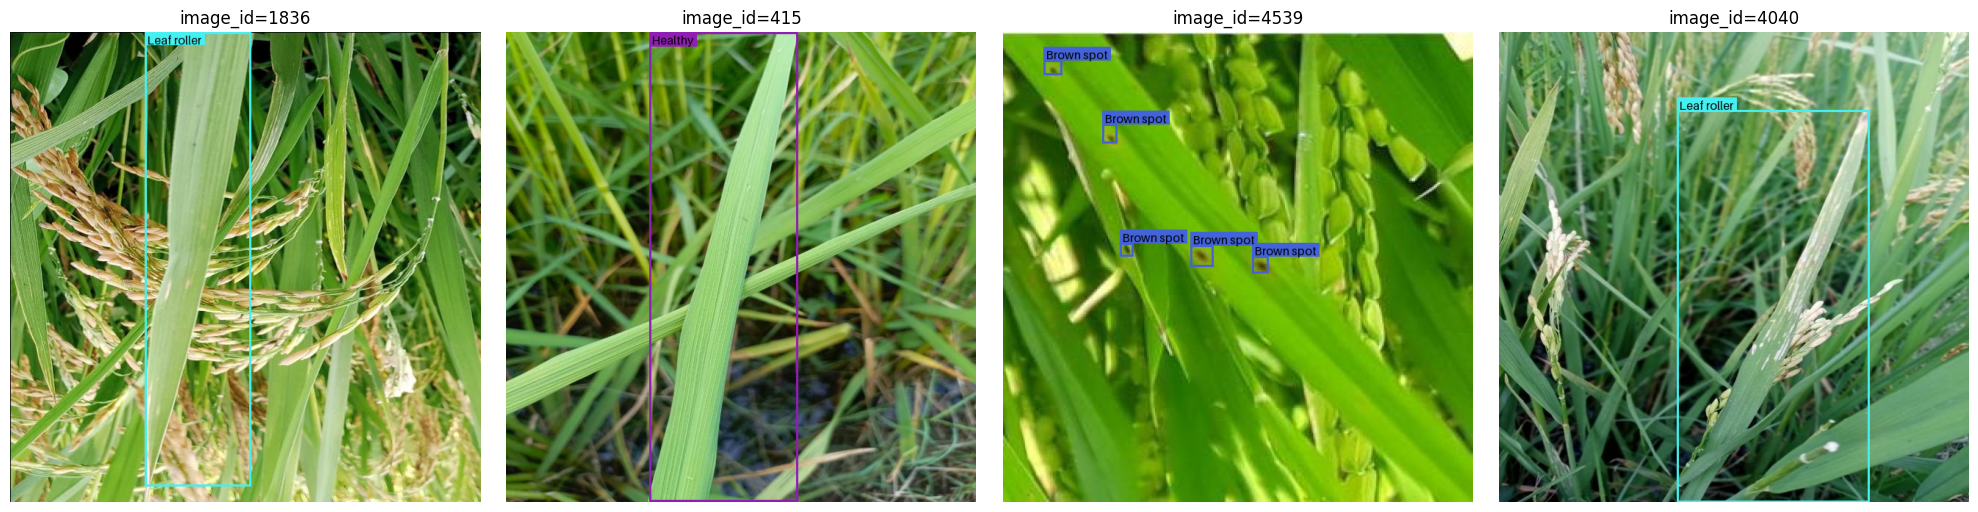

In [10]:
split_data = load_canonical_split(DATASET_ROOT, "train", "_annotations.coco.json")
ann_by_image = {}
for ann in split_data.annotations:
    ann_by_image.setdefault(ann.image_id, []).append(ann)
images_by_id = {img.image_id: img for img in split_data.images}

sample_ids = random.sample(sorted(ann_by_image.keys()), 4)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, image_id in zip(axes, sample_ids):
    img_record = images_by_id[image_id]
    annotated = draw_annotated_image(DATASET_ROOT / "train" / img_record.file_name, img_record, ann_by_image[image_id])
    ax.imshow(annotated)
    ax.set_title(f"image_id={image_id}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 10. Training Configuration (Frozen Final Config)

Selected in Block 14 from 21 controlled screening experiments — see
`artifacts/reports/block14_final_model_selection.md` for the full,
evidence-based reasoning behind every hyperparameter below.

In [11]:
print(json.dumps(FINAL_CONFIG, indent=2))

{
  "seed": 42,
  "model_arch": "yolov8n.yaml",
  "pretrained": false,
  "data_yaml": "data/prepared/data.yaml",
  "image_size": 640,
  "batch_size": 16,
  "optimizer": "AdamW",
  "learning_rate": 0.001,
  "momentum": 0.9,
  "weight_decay": 0.0005,
  "scheduler": "linear",
  "flipud": 0.0,
  "fraction": 1.0,
  "epochs": 20,
  "patience": 8,
  "workers": 2,
  "device": "auto"
}


## 11. Model Construction (Compliant — No External Pretrained Weights)

`build_compliant_model` refuses to run if `pretrained=True` or if the
architecture argument looks like a checkpoint file (`.pt`/`.pth`/`.ckpt`) —
see `src/agridata/training/train.py`.

In [12]:
compliant_model = build_compliant_model(FINAL_CONFIG["model_arch"], pretrained=False)
print(f"Model built from architecture-only definition '{FINAL_CONFIG['model_arch']}'. Task: {compliant_model.task}")
print("No external checkpoint was referenced or downloaded (YOLO_OFFLINE enforced).")

Model built from architecture-only definition 'yolov8n.yaml'. Task: detect
No external checkpoint was referenced or downloaded (YOLO_OFFLINE enforced).


## 12. Training (or Loading the Final Model)

`SKIP_TRAINING = True` (default) loads the already-trained final model
(produced by Block 15 using this exact frozen configuration) instead of
retraining, so this notebook completes in a reasonable time when run top to
bottom. Set `SKIP_TRAINING = False` to reproduce the full training run from
scratch (~3.3 hours on this project's Apple Silicon / MPS hardware — see
`artifacts/reports/block15_final_training_summary.json` for the actual
measured duration).

In [13]:
SKIP_TRAINING = True

FINAL_WEIGHTS_PATH = PROJECT_ROOT / "runs" / "detect" / "final" / "final_model" / "weights" / "best.pt"

if SKIP_TRAINING:
    assert FINAL_WEIGHTS_PATH.exists(), (
        f"SKIP_TRAINING=True but no existing final weights found at {FINAL_WEIGHTS_PATH}. "
        "Set SKIP_TRAINING=False to train from scratch, or run scripts/run_final_training.py first."
    )
    print(f"SKIP_TRAINING=True: loading existing final weights from {FINAL_WEIGHTS_PATH}")
else:
    print("SKIP_TRAINING=False: running full training from the frozen final configuration.")
    print("This reproduces Block 15's training run and will take several hours.")
    extra_kwargs = {
        "optimizer": FINAL_CONFIG["optimizer"], "lr0": FINAL_CONFIG["learning_rate"],
        "momentum": FINAL_CONFIG["momentum"], "weight_decay": FINAL_CONFIG["weight_decay"],
        "patience": FINAL_CONFIG["patience"], "flipud": FINAL_CONFIG.get("flipud", 0.0),
    }
    result = run_training(
        model_arch=FINAL_CONFIG["model_arch"],
        data_yaml=PREPARED_DIR / "data.yaml",
        output_project=PROJECT_ROOT / "runs" / "detect" / "final",
        run_name="final_model_notebook_rerun",
        image_size=FINAL_CONFIG["image_size"],
        batch_size=FINAL_CONFIG["batch_size"],
        epochs=FINAL_CONFIG["epochs"],
        device=detect_device(),
        seed=SEED,
        workers=FINAL_CONFIG["workers"],
        fraction=FINAL_CONFIG["fraction"],
        plots=True,
        validate=True,
        extra_train_kwargs=extra_kwargs,
    )
    FINAL_WEIGHTS_PATH = Path(result["best_weights"])
    print(f"Training complete. Best weights: {FINAL_WEIGHTS_PATH}")

SKIP_TRAINING=True: loading existing final weights from /Users/macbookpro/Projects/agridata/runs/detect/final/final_model/weights/best.pt


## 13. Validation & Evaluation (mAP@0.5, F1)

Delegates to `scripts/evaluate.py`, run as a subprocess. This is
intentional, not a shortcut: a Block 16 clean-environment reproduction test
found that running Ultralytics' native `val()` and this project's local F1
prediction-collection in the *same* process corrupts MPS backend state on
this hardware; `evaluate.py` runs each stage in its own subprocess to avoid
this reliably. See `artifacts/audit/block16_clean_reproduction_test.md`.

Test-set ground truth is never used here or anywhere in this pipeline for
tuning — only `valid` is evaluated in this notebook.

In [14]:
subprocess.run(
    [sys.executable, str(PROJECT_ROOT / "scripts" / "evaluate.py"),
     "--weights", str(FINAL_WEIGHTS_PATH),
     "--split", "valid",
     "--prepared-dir", str(PREPARED_DIR),
     "--conf-threshold", "0.25"],
    check=True, cwd=PROJECT_ROOT,
)

with open(PROJECT_ROOT / "artifacts" / "reports" / "evaluation_valid.json") as f:
    eval_report = json.load(f)

2026-09-18 06:10:31 | INFO     | agridata.scripts.evaluate | Device: mps
2026-09-18 06:10:31 | INFO     | agridata.scripts.evaluate | Running stage 'native_val' in a fresh subprocess (isolates MPS state)...


Ultralytics 8.4.154 🚀 Python-3.11.16 torch-2.14.0 MPS (Apple M1 Pro)
YOLOv8n summary (fused): 72 layers, 3,007,793 parameters, 0 gradients, 8.1 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 137.5±81.4 MB/s, size: 38.1 KB)
val: Scanning /Users/macbookpro/Projects/agridata/data/prepared/valid/labels.cache... 2106 images, 13 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2106/2106 736.1Mit/s 0.0s
val: /Users/macbookpro/Projects/agridata/data/prepared/valid/images/rtf_38_jpg.rf.2131d44635500a76448ff693d761baa1.jpg: 1 duplicate labels removed


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 0% ──────────── 1/132 1.8s/it 0.5s<3:56

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 1% ──────────── 2/132 1.5it/s 0.8s<1:25

...

2026-09-18 06:11:19 | INFO     | agridata.scripts.evaluate | Running stage 'local_f1' in a fresh subprocess (isolates MPS state)...


WARNING ⚠️ NMS time limit 2.050s exceeded


WARNING ⚠️ NMS time limit 27.000s exceeded


WARNING ⚠️ NMS time limit 27.000s exceeded


# Evaluation Report — split: `valid`

Weights: `/Users/macbookpro/Projects/agridata/runs/detect/final/final_model/weights/best.pt`  |  Git commit: `05725f1729bf6386c5cce84e508eec8f9b799ce8`

## Native metrics (Ultralytics, source of truth for mAP)

- mAP@0.5: 0.5620
- mAP@0.5:0.95: 0.3278
- Precision/Recall at Ultralytics' internal best-F1 point: 0.6073 / 0.5562

| canonical class | AP@0.5 |
|---|---:|
| Bacterial leaf blight | 0.3153 |
| Bacterial panicle blight | 0.4728 |
| Blast | 0.4147 |
| Brown spot | 0.2656 |
| False smut | 0.9009 |
| Healthy | 0.8580 |
| Leaf roller | 0.7829 |
| Leaf scald | 0.3475 |
| Narrow brown | 0.9411 |
| Sheath blight | 0.3507 |
| Tungro | 0.5328 |

## Local F1 metrics (implementation detail, confidence threshold = 0.25)

- Overall precision: 0.6568
- Overall recall: 0.2052
- Overall F1: 0.3127
- TP=1003 FP=524 FN=3885

| canonical class | precision | recall | F1 | TP | FP | FN |
|---|---:|---:|---:|---:|---:|---:|
| Leaf scald | 0.6436 | 0.1667 | 0.2648

## 14. Final Metrics — mAP@0.5 and F1-Score

In [15]:
native = eval_report["native_metrics"]
local = eval_report["local_f1_metrics"]

print("=== Official metrics (native Ultralytics mAP; local F1 — see src/agridata/metrics/detection.py) ===")
print(f"mAP@0.5:       {native['mAP50']:.4f}")
print(f"mAP@0.5:0.95:  {native['mAP50_95']:.4f}")
print(f"F1 (conf>=0.25): {local['overall']['f1']:.4f}  (precision={local['overall']['precision']:.4f}, recall={local['overall']['recall']:.4f})")
print()
print("Per-class AP@0.5:")
for cls, ap in native["per_class_AP50"].items():
    print(f"  {cls:28s} {ap:.4f}")

=== Official metrics (native Ultralytics mAP; local F1 — see src/agridata/metrics/detection.py) ===
mAP@0.5:       0.5620
mAP@0.5:0.95:  0.3278
F1 (conf>=0.25): 0.3127  (precision=0.6568, recall=0.2052)

Per-class AP@0.5:
  Bacterial leaf blight        0.3153
  Bacterial panicle blight     0.4728
  Blast                        0.4147
  Brown spot                   0.2656
  False smut                   0.9009
  Healthy                      0.8580
  Leaf roller                  0.7829
  Leaf scald                   0.3475
  Narrow brown                 0.9411
  Sheath blight                0.3507
  Tungro                       0.5328


## 15. Sample Prediction Visualization

Predicted bounding boxes on real validation images, generated by
`scripts/evaluate.py` above (a small, fixed number of samples).

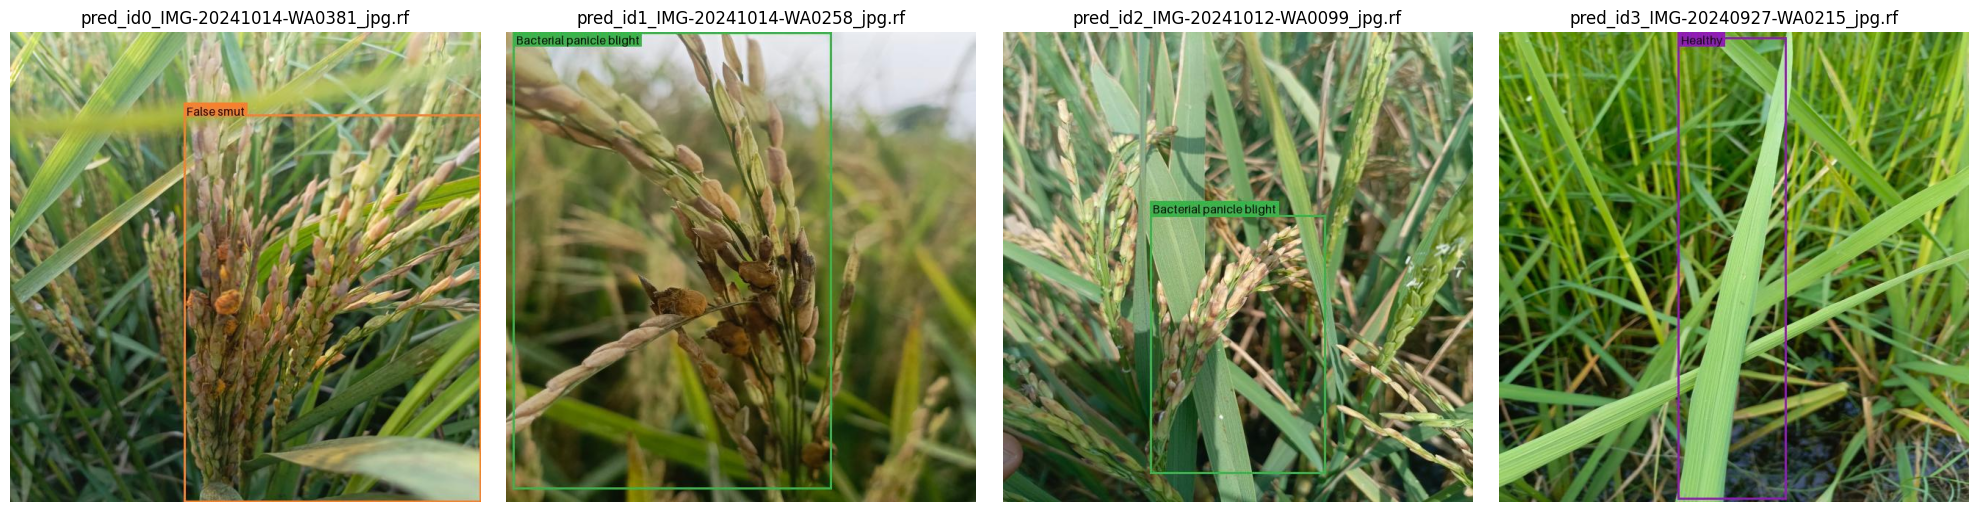

In [16]:
pred_samples = sorted((PROJECT_ROOT / "artifacts" / "figures" / "predictions").glob("pred_*.jpg"))[:4]

if pred_samples:
    fig, axes = plt.subplots(1, len(pred_samples), figsize=(20, 5))
    if len(pred_samples) == 1:
        axes = [axes]
    for ax, path in zip(axes, pred_samples):
        ax.imshow(mpimg.imread(path))
        ax.set_title(path.name[:35])
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No prediction samples were saved (no detection exceeded the confidence threshold in the sampled images).")

## 16. Final Model Path & Checksum

In [17]:
def sha256_of_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

print(f"Final model weights: {FINAL_WEIGHTS_PATH}")
print(f"SHA-256 checksum:    {sha256_of_file(FINAL_WEIGHTS_PATH)}")
print(f"File size:           {FINAL_WEIGHTS_PATH.stat().st_size / (1024 * 1024):.2f} MB")

Final model weights: /Users/macbookpro/Projects/agridata/runs/detect/final/final_model/weights/best.pt
SHA-256 checksum:    a48da07d91188b9985171bda8c2ebc745699fb21a1fa059291b014e6951b12e6
File size:           5.96 MB


## 17. Standalone Inference Demo

Loads the final weights fresh (independent of any training-time state) and
runs inference on one validation image.

In [18]:
from ultralytics import YOLO

inference_model = YOLO(str(FINAL_WEIGHTS_PATH))
sample_image_path = sorted((PREPARED_DIR / "valid" / "images").iterdir())[0]
results = inference_model.predict(str(sample_image_path), verbose=False)

print(f"Inference on {sample_image_path.name}: {len(results[0].boxes)} detection(s)")
for box in results[0].boxes:
    cls_name = CANONICAL_CLASSES[int(box.cls.item())]
    conf = float(box.conf.item())
    print(f"  {cls_name}: confidence={conf:.3f}")

Inference on 01-Brown-spot_jpg.rf.56a34f2f8a9a8ea9b3967c8a26dd9772.jpg: 0 detection(s)


## 18. Reproducibility Notes

In [19]:
with open(PROJECT_ROOT / "artifacts" / "reports" / "block15_final_training_summary.json") as f:
    training_summary = json.load(f)

print("=== Official final training run record (Block 15) ===")
print(f"Git commit:            {training_summary['git_commit']}")
print(f"Dataset manifest hash: {training_summary['dataset_manifest_hash']}")
print(f"Device:                {training_summary['device']}")
print(f"Duration:              {training_summary['duration_seconds'] / 3600:.2f} hours")
print(f"Clean-process load validation: {'PASS' if training_summary['clean_process_load_validation']['success'] else 'FAIL'}")

=== Official final training run record (Block 15) ===
Git commit:            20222441681255a2312dc4edfc52be1a06f4a85d
Dataset manifest hash: cf81abe0fbdae2740ad9eb27741f7fa0ef8cfcaabb18fd150ef16ba2ae55ab44
Device:                mps
Duration:              5.23 hours
Clean-process load validation: PASS


**Known reproducibility caveats (verified, not hedged speculation):**

- MPS backend (Apple Silicon) has confirmed non-deterministic kernels for
  `scatter_reduce_mps` and `index_put_with_accumulate_mps` (observed as
  explicit PyTorch `UserWarning`s during every training run in this
  project). Exact bit-for-bit training reproducibility is **not**
  guaranteed on this hardware — only reproducible *configuration* and
  *preprocessing* are claimed.
- Dataset preprocessing **is** verified bit-for-bit reproducible: rerunning
  `scripts/prepare_dataset.py` with the same seed produces a byte-for-byte
  identical manifest (Block 8, verified via a live rerun-and-diff).
- One confirmed exact-duplicate image across train/test (Block 2) is
  excluded from the prepared train manifest (Block 5).
- Two real environment/runtime defects were found and fixed via a
  clean-environment reproduction test (Block 16): a `numpy` version pin
  that broke a fresh `pip install`, and an MPS-backend crash on
  large-batch inference (worked around via chunking). See
  `artifacts/audit/block16_clean_reproduction_test.md` for the full
  investigation.

**Full audit trail**: `artifacts/audit/` (dataset forensic audit,
canonical-mapping validation, reproducibility checklist, clean-environment
reproduction test) and `artifacts/experiments/experiment_log.json` (21
controlled screening experiments underpinning the final configuration
choice, Blocks 10-14).